# Modular Multiplication — Generalisation Test

Replaces `(a+b) mod 97` with `(a*b) mod 97` and repeats H2 and H3.

**Research question:** Do the 1.90× architecture gap and 4.32× GELU advantage
replicate on multiplication — a harder, qualitatively different task?

**Est. T4 runtime: ~25 min** (25 seeds × ~1 min, CUDA graphs)

> Runtime → Change runtime type → T4 GPU

In [1]:
import torch, time, random, numpy as np, pandas as pd
import torch.nn as nn, torch.nn.functional as F
import matplotlib.pyplot as plt, warnings
from itertools import product as iproduct
from copy import deepcopy
from torch.amp import autocast

assert torch.cuda.is_available(), "Need T4 GPU!"
print("GPU:", torch.cuda.get_device_name(0))
torch.backends.cudnn.benchmark        = True
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32       = True
print("PyTorch:", torch.__version__)

P=97; TRAIN_FRACTION=0.2; CLIP=1.0; DEVICE="cuda"
LOG_EVERY = 2_000

def make_data(seed=0, op="add"):
    random.seed(seed)
    if op == "add":
        pairs = list(iproduct(range(P), range(P)))
        targets = lambda x: (x[:,0]+x[:,1])%P
    else:  # mul — exclude a=0 or b=0
        pairs = [(a,b) for a in range(1,P) for b in range(1,P)]
        targets = lambda x: (x[:,0]*x[:,1])%P
    random.shuffle(pairs)
    n = int(len(pairs)*TRAIN_FRACTION)
    def tt(d):
        x = torch.tensor(d, dtype=torch.long, device=DEVICE)
        return x, targets(x)
    return tt(pairs[:n]), tt(pairs[n:])

def accuracy(logits, y): return (logits.argmax(-1)==y).float().mean().item()

class MLP(nn.Module):
    def __init__(self, width=512, depth=4, act=nn.GELU):
        super().__init__()
        self.embed = nn.Embedding(P, width)
        layers = []
        for _ in range(depth): layers += [nn.Linear(width,width), act()]
        self.mlp = nn.Sequential(*layers)
        self.out = nn.Linear(width, P)
    def forward(self, x):
        return self.out(self.mlp(self.embed(x[:,0])+self.embed(x[:,1])))

class Transformer(nn.Module):
    def __init__(self, width=512, heads=4):
        super().__init__()
        self.embed     = nn.Embedding(P, width)
        self.pos_embed = nn.Parameter(torch.randn(2,width)*0.02)
        enc = nn.TransformerEncoderLayer(d_model=width, nhead=heads,
            dim_feedforward=width*4, activation="gelu", dropout=0.0,
            batch_first=True, norm_first=True)
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", UserWarning)
            self.transformer = nn.TransformerEncoder(enc, num_layers=1)
        self.out = nn.Linear(width, P)
    def forward(self, x):
        h = self.embed(x)+self.pos_embed
        return self.out(self.transformer(h).mean(1))

# ── CUDA-graph training with in-graph weight norm ──────────────────────────
def cuda_graph_train(model, optimizer, tx, ty, vx, vy,
                     steps=400_000, log_every=LOG_EVERY):
    """
    Full CUDA graph training loop.
    Weight norm is computed INSIDE the graph into a static buffer —
    zero CPU syncs during training steps.
    """
    model.train()

    # Static buffer for weight norm — written by graph, read at eval
    wn_buf = torch.zeros(1, device=DEVICE)

    # Warmup: 11 normal steps to trigger torch.compile
    for _ in range(11):
        optimizer.zero_grad(set_to_none=True)
        F.cross_entropy(model(tx), ty).backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), CLIP)
        optimizer.step()
    torch.cuda.synchronize()

    # Capture graph: forward + backward + clip + step + weight norm
    g = torch.cuda.CUDAGraph()
    optimizer.zero_grad(set_to_none=True)
    with torch.cuda.graph(g):
        loss_g = F.cross_entropy(model(tx), ty)
        loss_g.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), CLIP)
        optimizer.step()
        # Compute RMS weight norm inside graph — no CPU sync needed
        sq_sum = torch.zeros(1, device=DEVICE)
        n_params = 0
        for p in model.parameters():
            sq_sum += p.detach().pow(2).sum()
            n_params += p.numel()
        wn_buf.copy_(torch.sqrt(sq_sum / n_params))
    torch.cuda.synchronize()

    T_train = T_test = None
    history = []   # {step, train_acc, test_acc, weight_norm}
    t0 = time.time()

    for step in range(steps):
        g.replay()   # entire step: fwd+bwd+opt+wn — no Python overhead

        if step % log_every == 0:
            torch.cuda.synchronize()   # sync once per LOG_EVERY
            model.eval()
            with torch.no_grad(), autocast("cuda"):
                tr = accuracy(model(tx), ty)
                te = accuracy(model(vx), vy)
            model.train()
            wn = wn_buf.item()   # single scalar read, already on CPU buffer
            history.append({"step":step,"train":tr,"test":te,"weight_norm":wn})

            if T_train is None and tr >= 0.99: T_train = step
            if T_test  is None and te >= 0.99:
                T_test = step
                print(f"    GROKKED step={step} T_train={T_train} "
                      f"delay={T_test-T_train} wn={wn:.4f} "
                      f"t={(time.time()-t0)/60:.1f}m")
                break
            if step % (log_every*10) == 0:
                print(f"    step={step:>7} tr={tr:.3f} te={te:.3f} "
                      f"wn={wn:.3f} t={(time.time()-t0)/60:.1f}m")

    return T_train, T_test, history


def run_config(name, model_factory, opt_factory, seed=0, steps=400_000, op="add"):
    """Run a single configuration and return results."""
    print(f"  {name} seed={seed}")
    torch.manual_seed(seed)
    (tx,ty),(vx,vy) = make_data(seed, op=op)
    model = torch.compile(model_factory().to(DEVICE))
    opt   = opt_factory(model)
    T_train, T_test, history = cuda_graph_train(model, opt, tx, ty, vx, vy, steps)
    delay = (T_test-T_train) if (T_train and T_test) else None
    return {"name":name,"seed":seed,"T_train":T_train,"T_test":T_test,
            "delay":delay,"history":history,"model":model}

print("Setup complete. CUDA graph training ready.")


GPU: Tesla T4
PyTorch: 2.10.0+cu128
Setup complete. CUDA graph training ready.


In [3]:
SEEDS = list(range(5))

# ── H2-mul: MLP vs Transformer on multiplication ──────────────
print("=== H2-mul: Architecture on (a*b) mod 97 ===")
h2_rows = []
for arch, mf, of in [
    ("MLP",
     lambda: MLP(width=512, depth=4),
     lambda m: torch.optim.SGD(m.parameters(), lr=3e-2, weight_decay=1e-3, momentum=0.9)),
    ("Transformer",
     lambda: Transformer(),
     lambda m: torch.optim.AdamW(m.parameters(), lr=1e-3, weight_decay=5.0, capturable=True)),
]:
    print(f"\n  {arch} — {len(SEEDS)} seeds")
    for seed in SEEDS:
        t0 = time.time()
        r = run_config(arch, mf, of, seed=seed, steps=600_000, op="mul")
        print(f"    seed={seed} delay={r['delay']} t={(time.time()-t0)/60:.1f}m")
        h2_rows.append({"arch":arch,"seed":seed,
                         "T_train":r["T_train"],"T_test":r["T_test"],"delay":r["delay"]})

df_h2_mul = pd.DataFrame(h2_rows)
print("\nH2-mul summary:")
print(df_h2_mul.groupby("arch")["delay"].agg(["mean","std","count"]).to_string())
mul_ratio = (df_h2_mul[df_h2_mul.arch=="Transformer"]["delay"].mean() /
             df_h2_mul[df_h2_mul.arch=="MLP"]["delay"].mean())
print(f"TF/MLP ratio on multiplication: {mul_ratio:.2f}x  (addition was 1.90x)")

# ── H3-mul: Activation sweep on multiplication ────────────────
print("\n=== H3-mul: Activation on (a*b) mod 97 ===")
h3_rows = []
for act_name, act_cls in [("GELU",nn.GELU),("ReLU",nn.ReLU),("Tanh",nn.Tanh)]:
    print(f"\n  {act_name} — {len(SEEDS)} seeds")
    for seed in SEEDS:
        t0 = time.time()
        r = run_config(act_name,
            lambda a=act_cls: MLP(width=512, depth=4, act=a),
            lambda m: torch.optim.SGD(m.parameters(), lr=3e-2, weight_decay=1e-3, momentum=0.9),
            seed=seed, steps=400_000, op="mul")
        print(f"    seed={seed} delay={r['delay']} t={(time.time()-t0)/60:.1f}m")
        h3_rows.append({"act":act_name,"seed":seed,
                         "T_train":r["T_train"],"T_test":r["T_test"],"delay":r["delay"]})

df_h3_mul = pd.DataFrame(h3_rows)
print("\nH3-mul summary:")
print(df_h3_mul.groupby("act")["delay"].agg(["mean","std","count"]).to_string())
gelu_m = df_h3_mul[df_h3_mul.act=="GELU"]["delay"].mean()
relu_m = df_h3_mul[df_h3_mul.act=="ReLU"]["delay"].mean()
if gelu_m and relu_m:
    print(f"GELU/ReLU ratio on multiplication: {relu_m/gelu_m:.2f}x  (addition was 4.32x)")

=== H2-mul: Architecture on (a*b) mod 97 ===

  MLP — 5 seeds
  MLP seed=0
    step=      0 tr=0.011 te=0.011 wn=0.209 t=0.0m
    step=  20000 tr=1.000 te=0.820 wn=0.025 t=1.5m
    GROKKED step=24000 T_train=2000 delay=22000 wn=0.0222 t=1.8m
    seed=0 delay=22000 t=1.8m
  MLP seed=1
    step=      0 tr=0.011 te=0.010 wn=0.210 t=0.0m
    step=  20000 tr=1.000 te=0.542 wn=0.026 t=1.5m
    GROKKED step=28000 T_train=2000 delay=26000 wn=0.0213 t=2.1m
    seed=1 delay=26000 t=2.1m
  MLP seed=2
    step=      0 tr=0.007 te=0.011 wn=0.209 t=0.0m
    step=  20000 tr=1.000 te=0.304 wn=0.028 t=1.5m
    GROKKED step=26000 T_train=2000 delay=24000 wn=0.0219 t=2.0m
    seed=2 delay=24000 t=2.0m
  MLP seed=3
    step=      0 tr=0.015 te=0.010 wn=0.209 t=0.0m
    step=  20000 tr=1.000 te=0.624 wn=0.026 t=1.5m
    GROKKED step=24000 T_train=2000 delay=22000 wn=0.0224 t=1.8m
    seed=3 delay=22000 t=1.8m
  MLP seed=4
    step=      0 tr=0.012 te=0.010 wn=0.209 t=0.0m
    step=  20000 tr=1.000 te=0.448

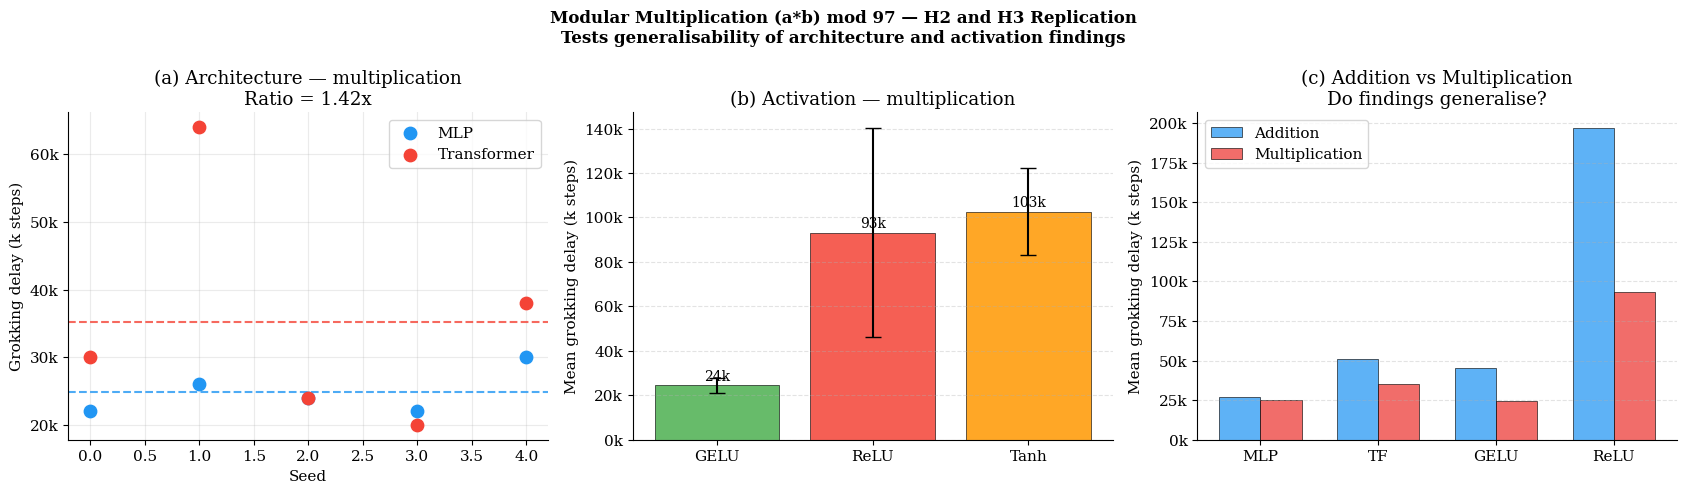

Saved: fig_mod_multiplication.png


In [4]:
plt.rcParams.update({"font.family":"serif","font.size":11,
    "axes.spines.top":False,"axes.spines.right":False})

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# (a) H2-mul: architecture comparison
ax = axes[0]
arch_colors = {"MLP":"#2196F3","Transformer":"#F44336"}
for arch in ["MLP","Transformer"]:
    sub = df_h2_mul[df_h2_mul.arch==arch].sort_values("seed")
    ax.scatter(sub.seed, sub.delay/1000, color=arch_colors[arch],
               s=80, zorder=3, label=arch)
    if sub.delay.notna().any():
        ax.axhline(sub.delay.mean()/1000, color=arch_colors[arch],
                   ls="--", lw=1.5, alpha=0.8)
ax.set(xlabel="Seed", ylabel="Grokking delay (k steps)",
       title=f"(a) Architecture — multiplication\nRatio = {mul_ratio:.2f}x")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v,_:f"{v:.0f}k"))
ax.legend(); ax.grid(alpha=0.25)

# (b) H3-mul: activation comparison
ax = axes[1]
act_colors = {"GELU":"#4CAF50","ReLU":"#F44336","Tanh":"#FF9800"}
s = df_h3_mul.groupby("act")["delay"].agg(["mean","std"]).reindex(["GELU","ReLU","Tanh"])
bars = ax.bar(s.index, s["mean"]/1000, yerr=s["std"]/1000,
              capsize=6, color=[act_colors[a] for a in s.index],
              alpha=0.85, edgecolor="black", lw=0.5)
for bar, m in zip(bars, s["mean"]/1000):
    if not np.isnan(m):
        ax.text(bar.get_x()+bar.get_width()/2, m+1, f"{m:.0f}k",
                ha="center", va="bottom", fontsize=10)
ax.set(ylabel="Mean grokking delay (k steps)",
       title="(b) Activation — multiplication")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v,_:f"{v:.0f}k"))
ax.grid(axis="y", ls="--", alpha=0.35)

# (c) Generalisation: addition vs multiplication
ax = axes[2]
# Addition results (from paper)
add_arch = {"MLP":26800, "Transformer":50800}
add_act  = {"GELU":45600, "ReLU":196800}
mul_arch = {arch: df_h2_mul[df_h2_mul.arch==arch]["delay"].mean()
            for arch in ["MLP","Transformer"]}
mul_act  = {act: df_h3_mul[df_h3_mul.act==act]["delay"].mean()
            for act in ["GELU","ReLU"]}
keys = ["MLP","TF","GELU","ReLU"]
add_v = [add_arch["MLP"],add_arch["Transformer"],add_act["GELU"],add_act["ReLU"]]
mul_v = [mul_arch.get("MLP",0),mul_arch.get("Transformer",0),
         mul_act.get("GELU",0),mul_act.get("ReLU",0)]
x = np.arange(4); w = 0.35
ax.bar(x-w/2, np.array(add_v)/1000, w, label="Addition",
       color="#42A5F5", alpha=0.85, edgecolor="black", lw=0.5)
ax.bar(x+w/2, np.array(mul_v)/1000, w, label="Multiplication",
       color="#EF5350", alpha=0.85, edgecolor="black", lw=0.5)
ax.set_xticks(x); ax.set_xticklabels(keys)
ax.set(ylabel="Mean grokking delay (k steps)",
       title="(c) Addition vs Multiplication\nDo findings generalise?")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v,_:f"{v:.0f}k"))
ax.legend(); ax.grid(axis="y", ls="--", alpha=0.35)

fig.suptitle("Modular Multiplication (a*b) mod 97 — H2 and H3 Replication\n"
             "Tests generalisability of architecture and activation findings",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("fig_mod_multiplication.png", dpi=150, bbox_inches="tight")
plt.show(); print("Saved: fig_mod_multiplication.png")
